# Project 3 Part 3: Object Detection with Faster R-CNN

In this notebook, you will learn about object detection - the task of not only classifying objects in images but also localizing them with bounding boxes. You'll work with Faster R-CNN, one of the most influential object detection architectures.

## Learning Objectives:
- Understand the difference between image classification and object detection
- Learn about Region Proposal Networks (RPN) and two-stage detectors
- Use pretrained Faster R-CNN models from torchvision
- Evaluate object detection performance using IoU and mAP metrics

***NOTE:***
When filling in the code, please REMOVE the `pass` and `None` statement.
DO NOT remove the TODO coding highlight in your submission.

### <span style="color: red;"> Grading Criteria for This Notebook (Part 3):</span>
- Code quality and implementation (2 pts)
- Performance benchmarks and analysis (2 pts)
- Analysis and answers to inline questions (2 pts)
- **Total for this notebook: 6 points**

In [1]:
# # Google Colab Setup (Comment out for local computer running)
################################################################################
# Uncomment and set the path to your project folder in Google Drive
################################################################################
# from google.colab import drive
# drive.mount('/content/drive')

# FOLDERNAME = 'cpsc8430/assignments/project3/'
# assert FOLDERNAME is not None, "[!] Enter the foldername."

# import sys
# sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))
# %cd /content/drive/My\ Drive/$FOLDERNAME

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader, Dataset

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm
import json

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

plt.rcParams['figure.figsize'] = (12, 8)

Using device: cpu


## Part 1: Understanding Object Detection

Object detection extends image classification by:
1. **Classification**: What objects are in the image?
2. **Localization**: Where are the objects located (bounding boxes)?

### Key Concepts:
- **Bounding Box**: Rectangle defined by (x_min, y_min, x_max, y_max) or (x, y, width, height)
- **IoU (Intersection over Union)**: Metric to measure bounding box overlap
- **Region Proposal Network (RPN)**: Network that proposes candidate object regions
- **Non-Maximum Suppression (NMS)**: Removes duplicate detections
- **mAP (mean Average Precision)**: Standard metric for object detection

### Question 1: Object Detection Fundamentals

**a) What is the difference between object detection and image classification? Why is object detection more challenging?**

$\color{blue}{\textit{Your Answer:}}$

**b) Explain what IoU (Intersection over Union) measures and why it's important for object detection.**

$\color{blue}{\textit{Your Answer:}}$

## Part 2: Load Pretrained Faster R-CNN

We'll start by using a pretrained Faster R-CNN model to detect objects in images.

In [2]:
# COCO class names (91 classes)
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

def load_pretrained_fasterrcnn():
    """
    Load pretrained Faster R-CNN model
    """
    # Load pretrained model on COCO dataset
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    model.eval()
    return model

# Load model
model_pretrained = load_pretrained_fasterrcnn()
model_pretrained = model_pretrained.to(device)

print("Pretrained Faster R-CNN loaded successfully!")
print(f"Model trained on COCO dataset with {len(COCO_INSTANCE_CATEGORY_NAMES)} classes")

/Users/stevenzinn/Desktop/Deep Learning/Project3/vpy/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/stevenzinn/Desktop/Deep Learning/Project3/vpy/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /Users/stevenzinn/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 160M/160M [00:02<00:00, 63.6MB/s]


Pretrained Faster R-CNN loaded successfully!
Model trained on COCO dataset with 91 classes


## Part 3: Inference with Pretrained Model

Let's test the pretrained model on some images.

**Instructions (TODO):**
- Place exactly 5 images into the test images folder used by this notebook: `cpsc8430/datasets/test_imgs/`
    - Create the folder if it doesn't exist.
    - Common formats: `.jpg`, `.jpeg`, `.png`.
    - Filenames can be arbitrary.
- These 5 images will be used to test the performance of the pre-loaded Faster R-CNN detector.
- After adding the images, run the inference cell (the cell that lists files in `cpsc8430/datasets/test_imgs/` and calls `detect_objects` / `visualize_detections`) to see detection outputs and inspect confidence scores.
- For debugging, you can lower the detection threshold (e.g., 0.05) in that cell to show more proposals, then raise it (e.g., 0.5) for stricter detections.

In [3]:
def detect_objects(model, image_path, threshold=0.5, device='cpu'):
    """
    Detect objects in an image

    Args:
        model: Faster R-CNN model
        image_path: Path to image file
        threshold: Confidence threshold for detections
        device: Device to run inference on

    Returns:
        predictions: Dictionary with boxes, labels, and scores
    """
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transforms.ToTensor()(image).unsqueeze(0).to(device)

    # Inference
    model.eval()
    with torch.no_grad():
        predictions = model(image_tensor)[0]

    # Filter by threshold
    keep = predictions['scores'] > threshold
    boxes = predictions['boxes'][keep].cpu().numpy()
    labels = predictions['labels'][keep].cpu().numpy()
    scores = predictions['scores'][keep].cpu().numpy()

    return {
        'boxes': boxes,
        'labels': labels,
        'scores': scores,
        'image': image
    }


def visualize_detections(image, boxes, labels, scores, class_names, threshold=0.5):
    """
    Visualize object detections on image
    """
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    for box, label, score in zip(boxes, labels, scores):
        if score >= threshold:
            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1

            # Draw bounding box
            rect = patches.Rectangle(
                (x1, y1), width, height,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

            # Add label
            label_text = f'{class_names[label]}: {score:.2f}'
            ax.text(
                x1, y1 - 5, label_text,
                bbox=dict(facecolor='red', alpha=0.5),
                fontsize=10, color='white'
            )

    ax.axis('off')
    plt.tight_layout()
    plt.show()


=== Processing: /Users/stevenzinn/Pictures/archive/5/00a5be32d303e480.jpg ===
Detections: 30
  1. person - score: 0.99 - box: [618.2647094726562, 130.3504638671875, 818.0361938476562, 556.9925537109375]
  2. person - score: 0.98 - box: [738.2786254882812, 0.0, 866.071533203125, 594.9627075195312]
  3. person - score: 0.98 - box: [543.4716186523438, 307.0701904296875, 799.9118041992188, 725.4407348632812]
  4. chair - score: 0.86 - box: [877.8010864257812, 157.36659240722656, 1018.100830078125, 502.1549377441406]
  5. chair - score: 0.82 - box: [969.4622192382812, 172.4259796142578, 1022.8552856445312, 433.36798095703125]
  6. cup - score: 0.54 - box: [198.93055725097656, 133.35829162597656, 348.658203125, 207.46324157714844]
  7. oven - score: 0.36 - box: [21.7432861328125, 168.01226806640625, 773.1728515625, 679.5687866210938]
  8. bench - score: 0.25 - box: [567.6013793945312, 158.49168395996094, 1015.1260375976562, 486.3004455566406]
  9. person - score: 0.24 - box: [755.8230590820

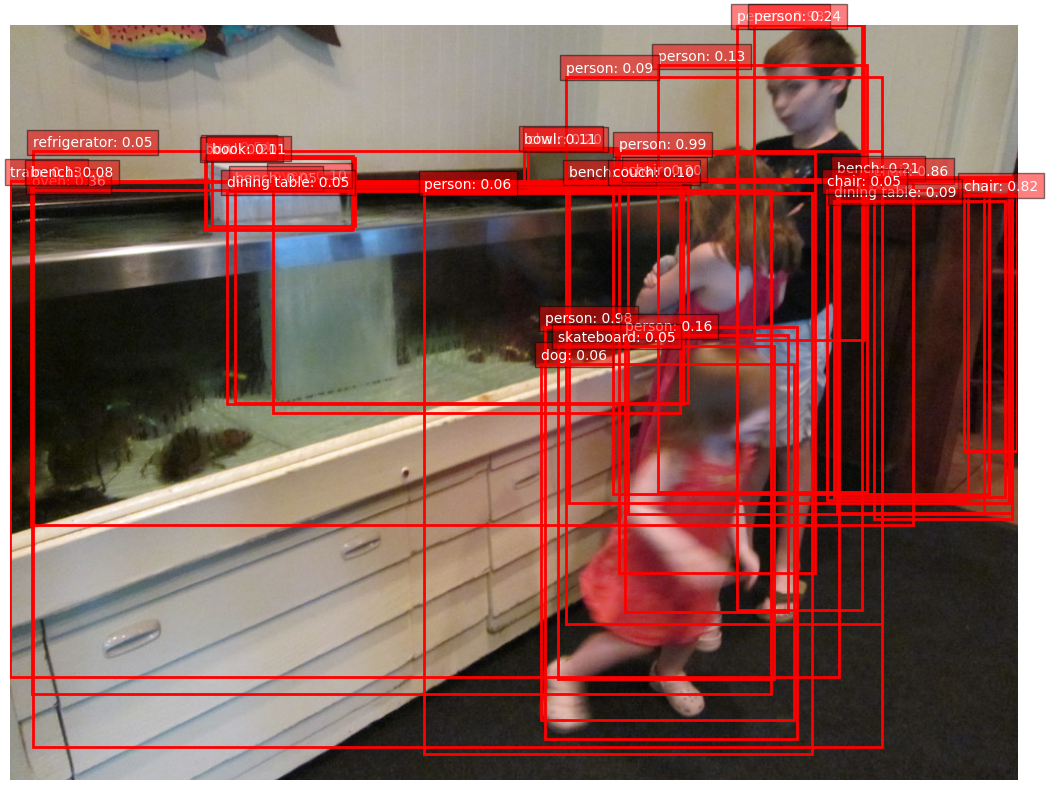


=== Processing: /Users/stevenzinn/Pictures/archive/5/00a60d051d75144f.jpg ===
Detections: 30
  1. toilet - score: 1.00 - box: [339.15057373046875, 660.6492919921875, 482.9569091796875, 812.9411010742188]
  2. bottle - score: 0.87 - box: [668.6865844726562, 551.4120483398438, 680.9290161132812, 579.2347412109375]
  3. bottle - score: 0.79 - box: [645.2620849609375, 550.8262939453125, 660.6431274414062, 590.2195434570312]
  4. bottle - score: 0.71 - box: [626.1673583984375, 558.0466918945312, 639.2539672851562, 589.28125]
  5. cup - score: 0.70 - box: [604.0428466796875, 565.0665283203125, 624.419921875, 592.7020263671875]
  6. sink - score: 0.64 - box: [543.5684204101562, 589.4888305664062, 683.0, 686.4946899414062]
  7. cup - score: 0.55 - box: [573.4434204101562, 569.907958984375, 602.5826416015625, 590.912109375]
  8. cup - score: 0.54 - box: [585.1807861328125, 555.1998901367188, 602.7056274414062, 576.5719604492188]
  9. sink - score: 0.36 - box: [603.3209228515625, 590.5993041992

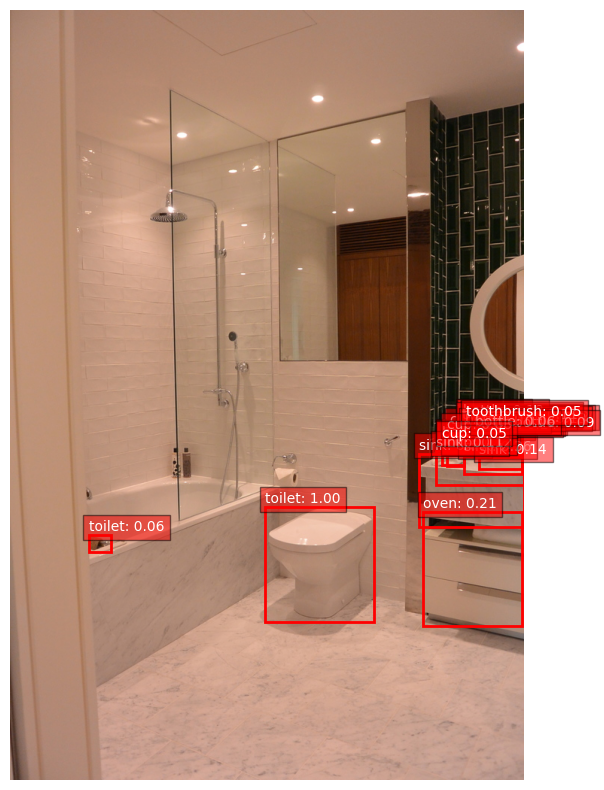


=== Processing: /Users/stevenzinn/Pictures/archive/5/0a41d984fa6937ca.jpg ===
Detections: 36
  1. oven - score: 0.99 - box: [660.010986328125, 441.241943359375, 843.8826293945312, 677.0799560546875]
  2. potted plant - score: 0.98 - box: [580.5283813476562, 288.5706481933594, 653.7760009765625, 373.0263977050781]
  3. refrigerator - score: 0.93 - box: [3.2302405834198, 249.4609832763672, 34.39076232910156, 664.685302734375]
  4. refrigerator - score: 0.93 - box: [0.0, 88.92381286621094, 75.1811294555664, 657.1660766601562]
  5. sink - score: 0.90 - box: [602.4584350585938, 380.4366455078125, 712.1580200195312, 400.35528564453125]
  6. vase - score: 0.66 - box: [607.5787963867188, 341.3819580078125, 640.19287109375, 374.8195495605469]
  7. sink - score: 0.38 - box: [241.01425170898438, 372.5830078125, 400.19232177734375, 390.2641296386719]
  8. oven - score: 0.38 - box: [211.53713989257812, 370.2421569824219, 443.30242919921875, 399.1802673339844]
  9. sink - score: 0.27 - box: [213.82

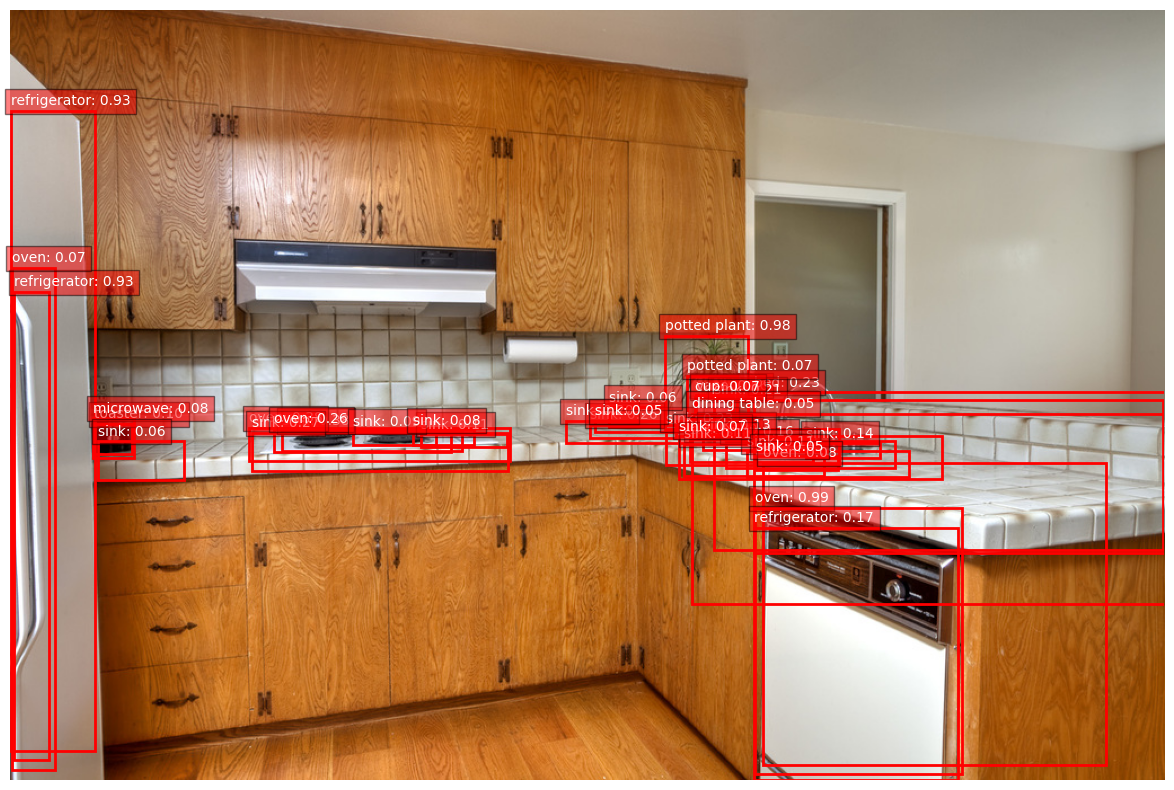


=== Processing: /Users/stevenzinn/Pictures/archive/5/0a68ceae0ff06341.jpg ===
Detections: 38
  1. person - score: 1.00 - box: [538.1212768554688, 228.62123107910156, 745.515625, 759.5911865234375]
  2. person - score: 1.00 - box: [336.5527648925781, 273.3145751953125, 606.8184204101562, 756.5931396484375]
  3. person - score: 1.00 - box: [0.0, 6.881572246551514, 437.3280334472656, 754.6509399414062]
  4. sink - score: 0.98 - box: [830.9842529296875, 527.7180786132812, 1024.0, 616.5625]
  5. bottle - score: 0.98 - box: [973.7176513671875, 414.298583984375, 1011.4099731445312, 532.3998413085938]
  6. bottle - score: 0.68 - box: [1006.1597290039062, 451.55523681640625, 1024.0, 542.3192749023438]
  7. bottle - score: 0.58 - box: [992.0795288085938, 431.64239501953125, 1021.61328125, 536.9133911132812]
  8. bottle - score: 0.56 - box: [857.9037475585938, 444.39208984375, 899.0595703125, 527.14453125]
  9. bottle - score: 0.52 - box: [990.2092895507812, 452.8138732910156, 1011.8988037109375

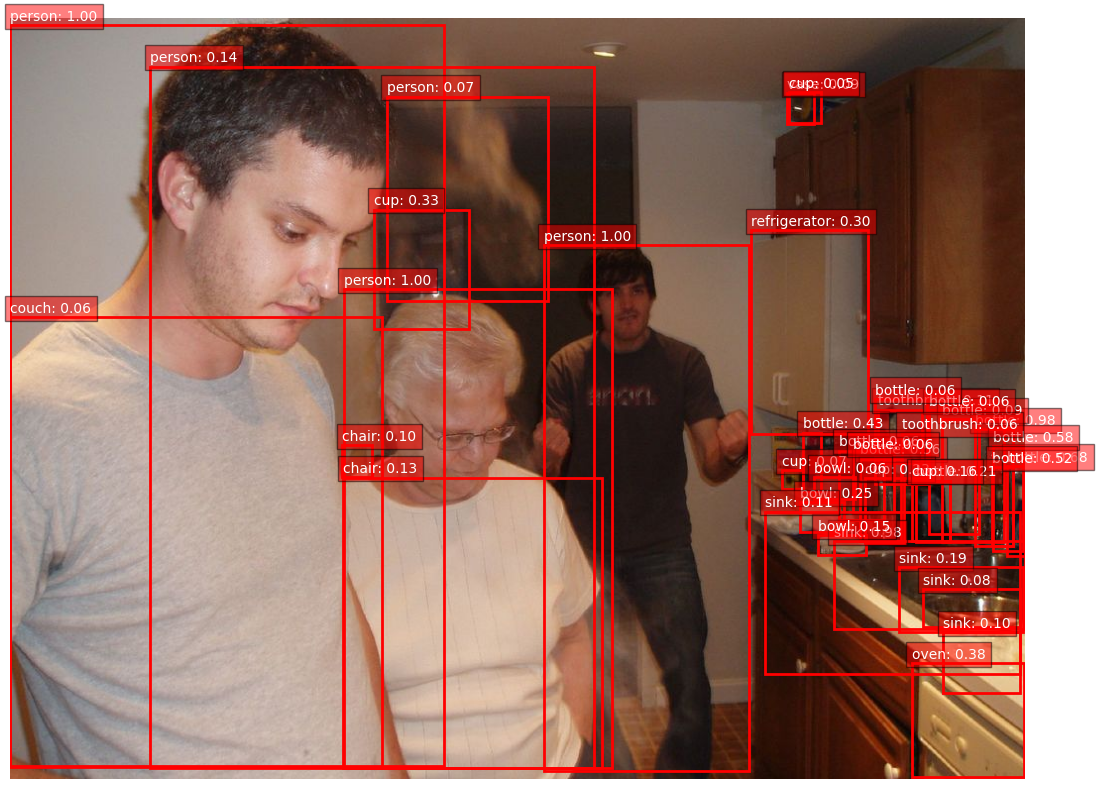


=== Processing: /Users/stevenzinn/Pictures/archive/5/0a6acb71e9635072.jpg ===
Detections: 57
  1. potted plant - score: 0.98 - box: [249.07955932617188, 394.2469787597656, 451.770751953125, 560.0233764648438]
  2. vase - score: 0.98 - box: [518.3452758789062, 400.1365661621094, 552.4796142578125, 436.7078857421875]
  3. potted plant - score: 0.97 - box: [506.53839111328125, 361.9729919433594, 565.82275390625, 434.5439453125]
  4. vase - score: 0.94 - box: [341.42633056640625, 507.103759765625, 394.0495910644531, 561.4678955078125]
  5. vase - score: 0.85 - box: [492.0347595214844, 413.5988464355469, 513.42626953125, 436.4534912109375]
  6. chair - score: 0.81 - box: [128.13223266601562, 731.5050048828125, 269.459228515625, 1011.7366943359375]
  7. chair - score: 0.77 - box: [351.6854553222656, 517.3423461914062, 465.3387451171875, 708.4596557617188]
  8. sink - score: 0.66 - box: [9.359055519104004, 555.72265625, 414.07830810546875, 717.4578857421875]
  9. potted plant - score: 0.59 -

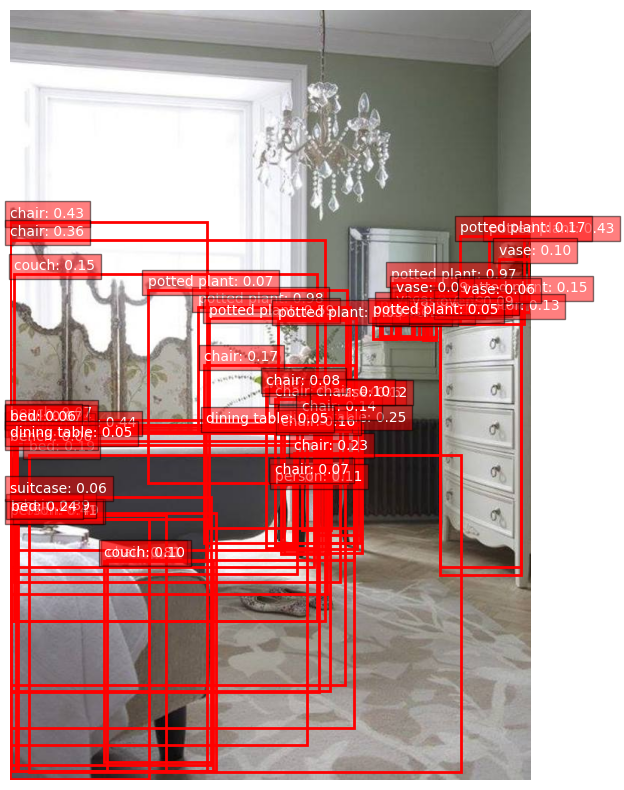

In [4]:
################################################################################
# TODO: Set the path to the test images folder
# *****START OF YOUR CODE*****

test_img_path = "/Users/stevenzinn/Pictures/archive/5"  # Set your test image path here

# *****END OF YOUR CODE*****
 ################################################################################

# Example: Test on a sample image
# NOTE: You'll need to provide your own test images
# For demonstration, let's create a simple test

# List files in the test image directory and process all images
if test_img_path is not None:
    test_images = sorted(os.listdir(test_img_path))
    if test_images:
        for img_name in test_images:
            img_path = os.path.join(test_img_path, img_name)

            # Skip non-image files
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                print(f"Skipping non-image file: {img_name}")
                continue

            print(f"\n=== Processing: {img_path} ===")
            try:
                # Lower threshold for demonstration to show more proposals
                predictions = detect_objects(model_pretrained, img_path, threshold=0.05, device=device)

                boxes = predictions['boxes']
                labels = predictions['labels']
                scores = predictions['scores']

                print(f"Detections: {len(boxes)}")
                for i, (lbl, sc, box) in enumerate(zip(labels, scores, boxes), 1):
                    print(f"  {i}. {COCO_INSTANCE_CATEGORY_NAMES[lbl]} - score: {sc:.2f} - box: {box.tolist()}")

                # Visualize detections (use same low threshold for demonstration)
                visualize_detections(
                    predictions['image'],
                    boxes,
                    labels,
                    scores,
                    COCO_INSTANCE_CATEGORY_NAMES,
                    threshold=0.05
                )
            except Exception as e:
                print(f"Failed to process {img_name}: {e}")
    else:
        print(f"No images found in the test directory: {test_img_path}")
else:
    print("Please set test_img_path to run object detection on your images.")

## Part 4: Evaluation Metrics

**TODO: Implement IoU and mAP calculations**

Requirements / Passing Criteria:
- calculate_iou:
    - Must return a float in [0, 1].
    - Correctly handle overlapping, non-overlapping, and identical boxes.
    - Must pass the notebook test: IoU([0,0,10,10], [5,5,15,15]) ≈ 0.1429 (within 1e-3).
- calculate_ap:
    - Must return a float in [0, 1].
    - Implement AP using 11-point interpolation as described in the notebook.
    - Correctly handle edge cases (no predictions, no targets).
    - For a perfect set of predictions (boxes match targets and scores are high), AP must equal 1.0; when there are no predictions, AP must equal 0.0.
- Implementation constraints:
    - Do not change the provided function signatures.
    - You may use numpy/torch utilities, but IoU logic should be explicit and robust.
    - Remove any `pass` or `None` placeholders in the implementation cells (do not remove the TODO highlight).
- Grading:
    - The grader will run unit tests that check the above behaviors and example outputs in the notebook. Failing those tests will reduce the score for Part 4.

In [5]:
def calculate_iou(box1, box2):
    """
    Calculate Intersection over Union (IoU) between two boxes

    Args:
        box1: [x_min, y_min, x_max, y_max]
        box2: [x_min, y_min, x_max, y_max]

    Returns:
        iou: IoU value between 0 and 1
    """
    ################################################################################
    # TODO: Implement IoU calculation
    # HINT:
    # 1. Calculate intersection area:
    #    - x_left = max(box1[0], box2[0])
    #    - y_top = max(box1[1], box2[1])
    #    - x_right = min(box1[2], box2[2])
    #    - y_bottom = min(box1[3], box2[3])
    #    - intersection = max(0, x_right - x_left) * max(0, y_bottom - y_top)
    # 2. Calculate union area:
    #    - area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    #    - area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    #    - union = area1 + area2 - intersection
    # 3. Return iou = intersection / union
    ################################################################################
    # *****START OF YOUR CODE*****
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])
    
    inter_width = max(0, x_right - x_left)
    inter_height = max(0, y_bottom - y_top)
    intersection_area = inter_width * inter_height

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = area1 + area2 - intersection_area

    iou = intersection_area / union_area
    # *****END OF YOUR CODE*****
    ################################################################################

    return iou


def calculate_ap(predictions, targets, iou_threshold=0.5):
    """
    Calculate Average Precision (AP) for a single class

    Args:
        predictions: List of predicted boxes with scores
        targets: List of ground truth boxes
        iou_threshold: IoU threshold for matching

    Returns:
        ap: Average precision value
    """
    # Sort predictions by confidence score
    if len(predictions) == 0:
        return 0.0

    predictions = sorted(predictions, key=lambda x: x['score'], reverse=True)

    tp = np.zeros(len(predictions))
    fp = np.zeros(len(predictions))

    # Track which ground truth boxes have been matched
    gt_matched = [False] * len(targets)

    for i, pred in enumerate(predictions):
        max_iou = 0
        max_idx = -1

        # Find best matching ground truth box
        for j, target in enumerate(targets):
            if gt_matched[j]:
                continue
            iou = calculate_iou(pred['box'], target['box'])
            if iou > max_iou:
                max_iou = iou
                max_idx = j

        # Check if it's a true positive
        if max_iou >= iou_threshold:
            tp[i] = 1
            gt_matched[max_idx] = True
        else:
            fp[i] = 1

    # Compute precision and recall
    tp_cumsum = np.cumsum(tp)
    fp_cumsum = np.cumsum(fp)

    recalls = tp_cumsum / len(targets) if len(targets) > 0 else np.zeros(len(tp_cumsum))
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum)

    # Compute AP using 11-point interpolation
    ap = 0
    for t in np.arange(0, 1.1, 0.1):
        if np.sum(recalls >= t) == 0:
            p = 0
        else:
            p = np.max(precisions[recalls >= t])
        ap += p / 11

    return ap


# Test IoU calculation
box1 = [0, 0, 10, 10]
box2 = [5, 5, 15, 15]
iou = calculate_iou(box1, box2)
print(f"IoU between {box1} and {box2}: {iou:.3f}")
print("Expected IoU: ~0.143")

IoU between [0, 0, 10, 10] and [5, 5, 15, 15]: 0.143
Expected IoU: ~0.143


### Question 2: Evaluation Metrics

**a) Explain how IoU is calculated. What IoU threshold is typically used to determine if a detection is correct?**

$\color{blue}{\textit{Your Answer:}}$

IoU is a predictive function that finds the overlap between predicted and observed or ground truth. IoU ranges from 0 to 1, with 0 indicating no overlap and 1 indicating complete overlap. 0.5 would indicate a 50% overlap, which is the threshold for a correct detection.

**b) What is Average Precision (AP)? How does mAP (mean Average Precision) extend this concept?**

$\color{blue}{\textit{Your Answer:}}$

AP represents the area under the bell curve of recall vs precision (quantity and quality) of the object detection. By taking the mean of the AP, we can figure out how well the model works on specific classes.

**c) Why is accuracy not a suitable metric for object detection?**

$\color{blue}{\textit{Your Answer:}}$

Accuracy only tells you if something is there, not where it is. This means that rewarding the model correctly gets difficult if it can't zone in on the actual object in the image.

## Part 5: Understanding Faster R-CNN Architecture

Let's explore the components of Faster R-CNN.

In [6]:
# Inspect Faster R-CNN architecture
model_inspect = fasterrcnn_resnet50_fpn(pretrained=True)

print("Faster R-CNN Components:")
print("\n1. Backbone (Feature Extractor):")
print(type(model_inspect.backbone))

print("\n2. Region Proposal Network (RPN):")
print(type(model_inspect.rpn))

print("\n3. RoI Heads (Classification and Regression):")
print(type(model_inspect.roi_heads))

print("\n4. Box Predictor:")
print(type(model_inspect.roi_heads.box_predictor))

# Count parameters
total_params = sum(p.numel() for p in model_inspect.parameters())
print(f"\nTotal parameters: {total_params:,}")

Faster R-CNN Components:

1. Backbone (Feature Extractor):
<class 'torchvision.models.detection.backbone_utils.BackboneWithFPN'>

2. Region Proposal Network (RPN):
<class 'torchvision.models.detection.rpn.RegionProposalNetwork'>

3. RoI Heads (Classification and Regression):
<class 'torchvision.models.detection.roi_heads.RoIHeads'>

4. Box Predictor:
<class 'torchvision.models.detection.faster_rcnn.FastRCNNPredictor'>

Total parameters: 41,755,286


### Question 3: Faster R-CNN Architecture

**a) Describe the main components of Faster R-CNN. What is the role of each component?**

$\color{blue}{\textit{Your Answer:}}$

1. Feature extractor. Like a pretrained CNN (ResNet or VGG for us). It turns the image into a feature map.
2. Region Proposal Network (RPN). It looks at the feature map and says there might be an object in these x areas.
3. RoI pooling and classifier. It takes the proposals from the RPN, looks at the features inside them, and decides exactly what the object is and fixes the box coordinates.

**b) What is a Region Proposal Network (RPN)? How does it improve upon previous methods like Selective Search?**

$\color{blue}{\textit{Your Answer:}}$

It uses a neural network on the GPU rather the the selective search on the CPU to scan the feature map. It is faster and more trainable.

**c) Why is Faster R-CNN called a 'two-stage' detector? What are the two stages?**

$\color{blue}{\textit{Your Answer:}}$

1. Stage 1 (Proposal). The RPN generates a bunch of candidate boxes. It doesn't know what they are yet, just that they aren't background.
2. Stage 2 (Classification). The network takes those specific candidates and runs a more intense analysis to classify the object and fix the box edges.

**d) Compare Faster R-CNN with one-stage detectors (like YOLO or SSD). What are the trade-offs?**

$\color{blue}{\textit{Your Answer:}}$

The one stage detectors skip the proposal and instead divide the image into grids. This is faster, but less accurate.

## Part 6: Advanced Topics

### Non-Maximum Suppression (NMS)

NMS is used to remove duplicate detections of the same object.

In [7]:
def non_max_suppression(boxes, scores, iou_threshold=0.5):
    """
    Apply Non-Maximum Suppression

    Args:
        boxes: Array of boxes [N, 4] in format [x_min, y_min, x_max, y_max]
        scores: Array of confidence scores [N]
        iou_threshold: IoU threshold for suppression

    Returns:
        keep: Indices of boxes to keep
    """
    ################################################################################
    # TODO: Implement NMS algorithm
    # HINT:
    # 1. Sort boxes by scores in descending order
    # 2. Iterate through sorted boxes:
    #    - Keep the box with highest score
    #    - Remove all boxes with IoU > threshold with this box
    # 3. Repeat until no boxes remain
    #
    # Alternative: Use torchvision.ops.nms for efficient implementation
    ################################################################################
    # *****START OF YOUR CODE*****
    keep = []
    order = scores.argsort()[::-1]
    
    while order.size > 0:
        i = order[0]
        keep.append(i)
        if order.size == 1:
            break
            
        ious = np.array([calculate_iou(boxes[i], boxes[j]) for j in order[1:]])
        inds = np.where(ious <= iou_threshold)[0]

        order = order[inds + 1]
    # *****END OF YOUR CODE*****
    ################################################################################

    return keep


# Demonstrate NMS
print("Non-Maximum Suppression (NMS) removes overlapping detections.")
print("PyTorch provides torchvision.ops.nms for efficient implementation.")

Non-Maximum Suppression (NMS) removes overlapping detections.
PyTorch provides torchvision.ops.nms for efficient implementation.


### Question 4: Advanced Concepts

**a) What is the purpose of Non-Maximum Suppression (NMS)? What problems would occur without it?**

$\color{blue}{\textit{Your Answer:}}$

NMS will remove the extra boxes on the objects. Without it, you get way more boxes on the objects than you need, leading to an unreadable image.

**b) What is Feature Pyramid Network (FPN)? How does it help object detection at different scales?**

$\color{blue}{\textit{Your Answer:}}$

Top-down pathway architecture to identify the background and foreground objects well. Bottom layers have high resolution while the top layers have high semantics.